# System Design Flow Verifier - LangGraph Multi-Agent Review

## Scenario
This notebook verifies and improves a textual system-design flow by sending it through specialized reviewer agents for Security, Backend, and Performance. An Improver agent rewrites the flow, a Summarization agent prepares the final answer, real search tools provide external context, and a Human-in-the-Loop interruption is used before the final output.

## How agents communicate through state
The graph uses a shared state object so each node can read the current candidate flow and publish only its own delta. The three reviewer agents run in parallel, so the state intentionally separates append-only audit fields from the latest per-reviewer result map.

### State fields and what they contain
- `current_flow`: the candidate flow currently under review
- `conversation`: append-only audit log of what each node said or did
- `review_results`: latest result per reviewer for the current pass; each reviewer overwrites only its own key so parallel execution stays safe
- `improvement_log`: append-only record of applied changes
- `tool_traces`: append-only record of tool outputs used by nodes
- `loop_count`: number of automated improve-and-rerun cycles already used
- `last_human_message`: the latest revision note from the human reviewer
- `approval_status`: whether the current candidate is pending, approved, or rejected
- `final_output`: final summary prepared by the summarization node

### Which agent touches which fields
- Security, Backend, and Performance read `current_flow` and write `review_results`, `conversation`, and `tool_traces`
- The review router reads `review_results` and writes one audit message into `conversation`
- The Improver reads `current_flow`, `review_results`, and `last_human_message`, then writes `current_flow`, `improvement_log`, `conversation`, `loop_count`, `last_human_message`, and `approval_status`
- Human Review reads `current_flow`, `review_results`, and `loop_count`, then writes `approval_status`, `last_human_message`, and `conversation`
- Summarization reads the whole state history slice that matters for output and writes `final_output`, `conversation`, and `tool_traces`

## Scope for this iteration
This notebook now implements the first real-agent iteration: GPT-backed reviewer, improver, and summarization agents run inside the LangGraph workflow, the tools are invoked explicitly inside the nodes so the execution stays easy to inspect, and the Google Colab helper cells are intentionally kept at the end of the notebook.

## Reference patterns reused
- Interrupts notebook: interrupt, InMemorySaver, checkpoint inspection, state-history inspection, graph visualization helpers
- Simple Graphs Part 2: conditional routing in StateGraph
- Checkpointers Part 1: execution with thread-scoped checkpoints

In [ ]:
%pip install -q langgraph langchain langchain-openai langchain-community python-dotenv ddgs

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_DIR = Path.cwd()
ENV_PATH = PROJECT_DIR / '.env'
load_dotenv(ENV_PATH, override=False)

openai_key = os.getenv('OPENAI_KEY')
if not openai_key:
    raise RuntimeError('OPENAI_KEY is not set. Add it to the local .env or export it before running the agent cells.')

print(f'Using environment file: {ENV_PATH}')
print(f'OPENAI_KEY present: {bool(openai_key)}')

Using environment file: d:\CodingProjects\SoftUniAgentWorkflows\LangGraph-simple-project\.env
OPENAI_KEY present: True


In [ ]:
import json
import logging
import operator
import sys
from datetime import datetime, timezone
from pprint import pformat
from typing import Annotated, Any, TypedDict
from urllib.parse import quote_plus
from uuid import uuid4

from IPython.display import HTML, Image, display
from langchain.agents import create_agent
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities.duckduckgo_search import DuckDuckGoSearchAPIWrapper
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.base import BaseCheckpointSaver
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command, Interrupt, interrupt
from pydantic import BaseModel, Field

def merge_review_results(a: dict[str, dict[str, str] | None], b: dict[str, dict[str, str] | None]) -> dict[str, dict[str, str] | None]:
    return {**a, **b}

class UtcMillisFormatter(logging.Formatter):
    def formatTime(self, record, _datefmt=None):
        _ = _datefmt
        timestamp = datetime.fromtimestamp(record.created, timezone.utc)
        return timestamp.isoformat(timespec='milliseconds').replace('+00:00', 'Z')

logger = logging.getLogger('system_design_flow_verifier')
logger.setLevel(logging.INFO)
logger.handlers.clear()
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(UtcMillisFormatter('%(asctime)-24s --- %(message)s'))
logger.addHandler(stream_handler)
logger.propagate = False

def get_active_comments(state) -> list[dict[str, str]]:
    return [comment for comment in state.get('review_results', {}).values() if comment is not None]

def stringify_content(content: Any) -> str:
    if isinstance(content, str):
        return content
    return json.dumps(content, ensure_ascii=True)

def format_conversation(conversation: list[str], limit: int = 12) -> str:
    if not conversation:
        return '- None yet.'
    return '\n'.join(f'- {item}' for item in conversation[-limit:])

def limit_words(text: str, max_words: int = 200) -> str:
    words = text.split()
    return ' '.join(words[:max_words])

def build_chat_model(model_name: str) -> ChatOpenAI:
    return ChatOpenAI(
        model=model_name,
        api_key=os.environ['OPENAI_API_KEY'],
        timeout=120,
        max_retries=2,
    )

def print_interrupts(interrupts: list[Interrupt]) -> None:
    for item in interrupts:
        display(HTML(f'<div style="border: 1px dashed red; margin: 5px; padding: 10px; white-space: pre-wrap;">{item.value}</div>'))

def display_graph(runnable: Runnable) -> None:
    try:
        display(Image(data=runnable.get_graph().draw_mermaid_png(), format='png'))
    except Exception as exc:
        logger.info(f'PNG graph rendering failed: {exc}')
        logger.info('ASCII fallback:')
        runnable.get_graph().print_ascii()

def explore_checkpoints(checkpointer: BaseCheckpointSaver, config: RunnableConfig) -> None:
    checkpoints = list(checkpointer.list(config))
    logger.info(f'There are {len(checkpoints)} checkpoints in total:')
    for checkpoint in reversed(checkpoints):
        for line in str(checkpoint).splitlines():
            logger.info(line)

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig) -> None:
    state_history = list(compiled_state_graph.get_state_history(config))
    for snapshot in reversed(state_history):
        logger.info(f"Step: {snapshot.metadata['step']}")
        logger.info('Current state:')
        for line in pformat(snapshot.values).splitlines():
            logger.info(line)
        logger.info(f'Next: {snapshot.next}')
        logger.info('')

def show_state(snapshot) -> None:
    logger.info(f'Interrupt count: {len(snapshot.interrupts)}')
    for line in pformat(snapshot.values).splitlines():
        logger.info(line)

In [ ]:
WEB_SEARCH_TOOL = DuckDuckGoSearchResults(
    name='web_search',
    description='Search current architecture and system-design best practices. Input should be a focused search query.',
    num_results=4,
    output_format='list',
)
YOUTUBE_SEARCH_WRAPPER = DuckDuckGoSearchAPIWrapper(max_results=5)

@tool
def youtube_search(query: str) -> str:
    """Return the first relevant YouTube video URL for an architecture topic."""
    results = YOUTUBE_SEARCH_WRAPPER.results(f'site:youtube.com/watch {query}', max_results=5)
    for item in results:
        link = item.get('link', '')
        if 'youtube.com/watch' in link or 'youtu.be/' in link:
            return link
    return f"https://www.youtube.com/results?search_query={quote_plus(query)}"

In [5]:
class WorkflowState(TypedDict):
    current_flow: str
    conversation: Annotated[list[str], operator.add]
    review_results: Annotated[dict[str, dict[str, str] | None], merge_review_results]
    improvement_log: Annotated[list[str], operator.add]
    tool_traces: Annotated[list[str], operator.add]
    loop_count: int
    last_human_message: str
    approval_status: str
    final_output: str

In [ ]:
class ReviewDecision(BaseModel):
    has_major_comment: bool = Field(description='Whether the reviewer found one major issue that should change the flow.')
    rationale: str = Field(description='One short reason supporting the decision.')
    recommendation: str = Field(description='Exactly one major action-oriented recommendation, or an empty string if no major comment is needed.')

class ImprovementResult(BaseModel):
    updated_flow: str = Field(description='The rewritten system-design flow.')
    change_summary: str = Field(description='A short explanation of what changed and why.')

class SummaryResult(BaseModel):
    improvements_summary: str = Field(description='A concise summary of the accepted improvements in 200 words or fewer.')

REVIEWER_PROMPTS = {
    'Security': """
    You are the Security reviewer for a textual system-design flow. Use the supplied web-search findings as evidence.
    Return either no major comment or one major action-oriented comment. Ignore style and minor details. Focus only on the highest-impact security gap.
    """,
    'Backend': """
    You are the Backend reviewer for a textual system-design flow. Use the supplied web-search findings as evidence. 
    Return either no major comment or one major action-oriented comment. Ignore style and minor details. 
    Focus on correctness, durability, and service coordination.
    """,
    'Performance': """
    You are the Performance reviewer for a textual system-design flow. Use the supplied web-search findings as evidence.
    Return either no major comment or one major action-oriented comment. Ignore style and minor details. Focus on the highest-impact latency or throughput issue.
    """,
}
REVIEWER_SEARCH_QUERIES = {
    'Security': 'API gateway authentication authorization edge security best practices for service architectures',
    'Backend': 'transactional outbox pattern database first broker publish best practices',
    'Performance': 'acknowledge after database commit asynchronous event publication performance best practices',
}
IMPROVER_PROMPT = """You are the Improver agent. Rewrite the current flow using reviewer comments and optional human feedback. 
Keep the answer concrete and implementation-oriented. Return the updated flow plus a short explanation of what changed. Do not discuss anything else.
"""

SUMMARIZER_PROMPT = """You are the Summarization agent. Use the current flow, change log, and YouTube links to produce a concise final improvement summary under 200 words.
Keep the flow unchanged. Focus on what was improved and why it matters.
"""

REVIEWER_AGENTS = {
    reviewer: create_agent(
        model=build_chat_model('gpt-5-mini'),
        tools=None,
        system_prompt=prompt,
        name=f'{reviewer.lower()}_review_agent',
    )
    for reviewer, prompt in REVIEWER_PROMPTS.items()
}
IMPROVER_AGENT = create_agent(
    model=build_chat_model('gpt-5-mini'),
    tools=None,
    system_prompt=IMPROVER_PROMPT,
    name='improver_agent',
)
SUMMARIZER_AGENT = create_agent(
    model=build_chat_model('gpt-5-nano'),
    tools=None,
    system_prompt=SUMMARIZER_PROMPT,
    name='summarizer_agent',
)

def build_comment(reviewer: str, rationale: str, recommendation: str, reference: str) -> dict[str, str]:
    return {
        'reviewer': reviewer,
        'rationale': rationale,
        'recommendation': recommendation,
        'reference': reference,
    }

def parse_agent_json(agent_result: dict, schema: type[BaseModel]) -> BaseModel:
    raw_output = stringify_content(agent_result['messages'][-1].content)
    json_start = raw_output.find('{')
    if json_start == -1:
        raise ValueError(f'Agent did not return JSON: {raw_output}')

    parsed, _ = json.JSONDecoder().raw_decode(raw_output[json_start:])
    return schema.model_validate(parsed)

def run_reviewer_agent(reviewer: str, state: WorkflowState) -> tuple[ReviewDecision, str]:
    search_query = REVIEWER_SEARCH_QUERIES[reviewer]
    search_results = WEB_SEARCH_TOOL.invoke(search_query)
    agent_input = '\n'.join([
        f'Reviewer: {reviewer}',
        'Current flow:',
        state['current_flow'],
        '',
        'Recent conversation:',
        format_conversation(state['conversation']),
        '',
        'Web search findings:',
        stringify_content(search_results),
        '',
        'Return exactly one JSON object with keys has_major_comment, rationale, recommendation.',
        'If there is no major comment, set has_major_comment to false and recommendation to an empty string.',
    ])
    agent_result = REVIEWER_AGENTS[reviewer].invoke({'messages': [{'role': 'user', 'content': agent_input}]})
    tool_trace = f"[web_search] query={search_query} results={stringify_content(search_results)}"
    return parse_agent_json(agent_result, ReviewDecision), tool_trace

def security_review(state: WorkflowState) -> dict:
    logger.info('[Security] node is executing')
    decision, reference = run_reviewer_agent('Security', state)
    if not decision.has_major_comment:
        return {
            'review_results': {'Security': None},
            'conversation': ['[Security] No major comment.'],
            'tool_traces': [reference],
        }

    comment = build_comment(
        'Security',
        decision.rationale.strip(),
        decision.recommendation.strip(),
        reference,
    )
    return {
        'review_results': {'Security': comment},
        'conversation': [f"[Security] {comment['recommendation']}"],
        'tool_traces': [reference],
    }

def backend_review(state: WorkflowState) -> dict:
    logger.info('[Backend] node is executing')
    decision, reference = run_reviewer_agent('Backend', state)
    if not decision.has_major_comment:
        return {
            'review_results': {'Backend': None},
            'conversation': ['[Backend] No major comment.'],
            'tool_traces': [reference],
        }

    comment = build_comment(
        'Backend',
        decision.rationale.strip(),
        decision.recommendation.strip(),
        reference,
    )
    return {
        'review_results': {'Backend': comment},
        'conversation': [f"[Backend] {comment['recommendation']}"],
        'tool_traces': [reference],
    }

def performance_review(state: WorkflowState) -> dict:
    logger.info('[Performance] node is executing')
    decision, reference = run_reviewer_agent('Performance', state)
    if not decision.has_major_comment:
        return {
            'review_results': {'Performance': None},
            'conversation': ['[Performance] No major comment.'],
            'tool_traces': [reference],
        }

    comment = build_comment(
        'Performance',
        decision.rationale.strip(),
        decision.recommendation.strip(),
        reference,
    )
    return {
        'review_results': {'Performance': comment},
        'conversation': [f"[Performance] {comment['recommendation']}"],
        'tool_traces': [reference],
    }

def review_router(state: WorkflowState) -> dict:
    active_comments = get_active_comments(state)
    logger.info(f'[Review Router] Active major comments: {len(active_comments)}')
    return {
        'conversation': [f'[Review Router] Active major comments: {len(active_comments)}'],
    }

In [ ]:
def improver(state: WorkflowState) -> dict:
    logger.info('[Improver] node is executing')
    active_comments = get_active_comments(state)
    reviewer_notes = [
        f"- {comment['reviewer']}: {comment['recommendation']} (reason: {comment['rationale']})"
        for comment in active_comments
    ]
    human_feedback = state['last_human_message'].strip() or 'None.'
    agent_input = '\n'.join([
        'Current flow:',
        state['current_flow'],
        '',
        'Reviewer comments:',
        '\n'.join(reviewer_notes) if reviewer_notes else '- None.',
        '',
        f'Human feedback: {human_feedback}',
        '',
        'Recent conversation:',
        format_conversation(state['conversation']),
        '',
        'Return exactly one JSON object with keys updated_flow and change_summary.',
    ])
    agent_result = IMPROVER_AGENT.invoke({'messages': [{'role': 'user', 'content': agent_input}]})
    improvement = parse_agent_json(agent_result, ImprovementResult)
    updated_flow = improvement.updated_flow.strip() or state['current_flow']
    summary = improvement.change_summary.strip() or 'Updated the flow based on the latest feedback.'
    return {
        'current_flow': updated_flow,
        'improvement_log': [summary],
        'conversation': [f'[Improver] {summary}'],
        'loop_count': state['loop_count'] + 1,
        'last_human_message': '',
        'approval_status': 'pending',
    }

def human_review(state: WorkflowState) -> dict:
    logger.info('[Human Review] node is executing')
    active_comments = get_active_comments(state)
    reason = 'Automated review reached the loop limit.' if active_comments else 'Automated review found no more major comments.'
    prompt = {
        'reason': reason,
        'loop_count': state['loop_count'],
        'current_flow': state['current_flow'],
        'pending_comments': active_comments,
        'question': 'Reply with {\'action\': \'approve\'} or {\'action\': \'reject\', \'feedback\': \'...\'}',
    }
    response = interrupt(prompt)

    if isinstance(response, str):
        response = {'action': 'reject', 'feedback': response}

    action = response.get('action', 'reject').lower()
    feedback = response.get('feedback', '').strip()

    if action == 'approve':
        approval_status = 'approved'
    elif action in {'reject', 'revise'}:
        approval_status = 'rejected'
    else:
        raise ValueError(f"Unsupported human review action: {action}")

    return {
        'approval_status': approval_status,
        'last_human_message': feedback,
        'conversation': [f"[Human] action={action}; feedback={feedback or 'No additional feedback.'}"],
    }

def summarize(state: WorkflowState) -> dict:
    logger.info('[Summarization] node is executing')
    improvements = state['improvement_log'] or ['No automated improvements were necessary.']
    youtube_links = [youtube_search.invoke(item) for item in improvements]
    tool_traces = [
        f"[youtube_search] {improvement} -> {link}"
        for improvement, link in zip(improvements, youtube_links)
    ]
    agent_input = '\n'.join([
        'Final flow proposal:',
        state['current_flow'],
        '',
        'Applied changes:',
        '\n'.join(f'- {item}' for item in improvements),
        '',
        'YouTube references:',
        '\n'.join(f'- {link}' for link in youtube_links),
        '',
        'Recent conversation:',
        format_conversation(state['conversation']),
        '',
        'Return exactly one JSON object with the key improvements_summary.',
    ])
    agent_result = SUMMARIZER_AGENT.invoke({'messages': [{'role': 'user', 'content': agent_input}]})
    summary = limit_words(parse_agent_json(agent_result, SummaryResult).improvements_summary.strip())
    lines = [
        'Final flow proposal:',
        state['current_flow'],
        '',
        'Improvements summary:',
        summary,
        '',
        'Applied changes:',
    ]

    lines.extend([f'- {item}' for item in improvements])
    lines.append('')
    lines.append('YouTube references:')
    lines.extend([f'- {link}' for link in youtube_links])

    return {
        'final_output': '\n'.join(lines),
        'conversation': ['[Summarization] Final output prepared.'],
        'tool_traces': tool_traces,
    }

def route_after_reviews(state: WorkflowState) -> str:
    if not get_active_comments(state):
        return 'human_review'
    if state['loop_count'] < 2:
        return 'improver'
    return 'human_review'

def route_after_human_review(state: WorkflowState) -> str:
    if state['approval_status'] == 'approved':
        return 'summarize'
    elif state['approval_status'] == 'rejected':
        return 'improver'
    raise ValueError(f"Unsupported approval_status: {state['approval_status']}")

In [8]:
checkpointer = InMemorySaver()
graph_builder = StateGraph(WorkflowState)
graph_builder.add_node('security_review', security_review)
graph_builder.add_node('backend_review', backend_review)
graph_builder.add_node('performance_review', performance_review)
graph_builder.add_node('review_router', review_router)
graph_builder.add_node('improver', improver)
graph_builder.add_node('human_review', human_review)
graph_builder.add_node('summarize', summarize)

graph_builder.add_edge(START, 'security_review')
graph_builder.add_edge(START, 'backend_review')
graph_builder.add_edge(START, 'performance_review')
graph_builder.add_edge('security_review', 'review_router')
graph_builder.add_edge('backend_review', 'review_router')
graph_builder.add_edge('performance_review', 'review_router')
graph_builder.add_conditional_edges('review_router', route_after_reviews, ['improver', 'human_review'])
graph_builder.add_edge('improver', 'security_review')
graph_builder.add_edge('improver', 'backend_review')
graph_builder.add_edge('improver', 'performance_review')
graph_builder.add_conditional_edges('human_review', route_after_human_review, ['improver', 'summarize'])
graph_builder.add_edge('summarize', END)

graph = graph_builder.compile(checkpointer=checkpointer)

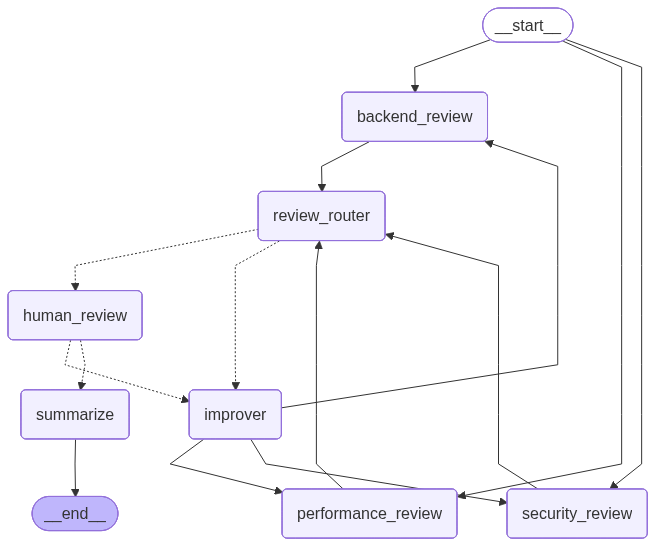

In [9]:
display_graph(graph)

In [10]:
def execute_workflow(user_request: str, thread_id: str | None = None) -> dict:
    thread_id = thread_id or f'workflow-{uuid4()}'
    config = {'configurable': {'thread_id': thread_id}}
    initial_state: WorkflowState = {
        'current_flow': user_request,
        'conversation': [f'[User] {user_request}'],
        'review_results': {},
        'improvement_log': [],
        'tool_traces': [],
        'loop_count': 0,
        'last_human_message': '',
        'approval_status': 'pending',
        'final_output': '',
    }
    graph.invoke(initial_state, config=config)
    snapshot = graph.get_state(config)
    return {'config': config, 'snapshot': snapshot}

def resume_workflow(config: RunnableConfig, human_response: dict[str, str] | str) -> dict:
    graph.invoke(Command(resume=human_response), config=config)
    snapshot = graph.get_state(config)
    return {'config': config, 'snapshot': snapshot}

In [11]:
sample_flow = 'Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.'
run = execute_workflow(sample_flow, thread_id='sample-approval-path')
show_state(run['snapshot'])

2026-05-10T13:54:56.655Z --- [Backend] node is executing
2026-05-10T13:54:56.656Z --- [Performance] node is executing
2026-05-10T13:54:56.656Z --- [Security] node is executing
2026-05-10T13:54:56.664Z --- [Review Router] Active major comments: 3
2026-05-10T13:54:56.665Z --- [Improver] node is executing
2026-05-10T13:54:56.666Z --- [Backend] node is executing
2026-05-10T13:54:56.666Z --- [Performance] node is executing
2026-05-10T13:54:56.666Z --- [Security] node is executing
2026-05-10T13:54:56.676Z --- [Review Router] Active major comments: 3
2026-05-10T13:54:56.678Z --- [Improver] node is executing
2026-05-10T13:54:56.679Z --- [Backend] node is executing
2026-05-10T13:54:56.680Z --- [Performance] node is executing
2026-05-10T13:54:56.680Z --- [Security] node is executing
2026-05-10T13:54:56.684Z --- [Review Router] Active major comments: 3
2026-05-10T13:54:56.686Z --- [Human Review] node is executing
2026-05-10T13:54:56.687Z --- Interrupt count: 1
2026-05-10T13:54:56.691Z --- {'appro

In [12]:
print_interrupts(run['snapshot'].interrupts)
explore_checkpoints(checkpointer, run['config'])
explore_state_history(graph, run['config'])

2026-05-10T13:54:56.837Z --- There are 10 checkpoints in total:
2026-05-10T13:54:56.837Z --- CheckpointTuple(config={'configurable': {'thread_id': 'sample-approval-path', 'checkpoint_ns': '', 'checkpoint_id': '1f14c77d-3fc3-62dc-bfff-824632ddda75'}}, checkpoint={'v': 4, 'ts': '2026-05-10T13:54:56.653589+00:00', 'id': '1f14c77d-3fc3-62dc-bfff-824632ddda75', 'channel_versions': {'__start__': '00000000000000000000000000000001.0.5160974771153934'}, 'versions_seen': {'__input__': {}}, 'updated_channels': ['__start__'], 'channel_values': {'__start__': {'current_flow': 'Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.', 'conversation': ['[User] Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.'], 'review_results': {}, 'improvement_log': [], 'tool_traces': [], 'loop_count': 0, 'last_human_message': '', 'approval_status': 'pending', 'final_output': '

In [13]:
approved = resume_workflow(run['config'], {'action': 'approve'})
show_state(approved['snapshot'])
print(approved['snapshot'].values['final_output'])

2026-05-10T13:54:58.116Z --- [Human Review] node is executing
2026-05-10T13:54:58.118Z --- [Summarization] node is executing
2026-05-10T13:54:58.122Z --- Interrupt count: 0
2026-05-10T13:54:58.124Z --- {'approval_status': 'approved',
2026-05-10T13:54:58.124Z ---  'conversation': ['[User] Client send request to Posts service which sends a '
2026-05-10T13:54:58.125Z ---                   'message to message broker and writes in the DB the '
2026-05-10T13:54:58.125Z ---                   'respective new post.',
2026-05-10T13:54:58.127Z ---                   '[Backend] Write to the database first and persist an outbox '
2026-05-10T13:54:58.127Z ---                   'event in the same transaction before publishing to the '
2026-05-10T13:54:58.127Z ---                   'broker.',
2026-05-10T13:54:58.118Z --- [Summarization] node is executing
2026-05-10T13:54:58.122Z --- Interrupt count: 0
2026-05-10T13:54:58.124Z --- {'approval_status': 'approved',
2026-05-10T13:54:58.124Z ---  'conversati

## Optional Google Colab Setup
These helper cells are intentionally placed at the end so the local development path stays first. In Google Colab, run the next cell before rerunning the notebook from the top so the OpenAI key is available through environment variables without being stored in notebook source.

In [ ]:
try:
    import importlib
    colab_module = importlib.import_module('google.colab')
except ImportError:
    print('Local runtime detected. Skip this cell.')
else:
    colab_key = colab_module.userdata.get('OPENAI_KEY')
    if not colab_key:
        raise RuntimeError('Add OPENAI_KEY to Colab secrets, run this cell, and then rerun the notebook from the top.')

    os.environ['OPENAI_KEY'] = colab_key
    os.environ['OPENAI_API_KEY'] = colab_key
    print('Loaded OPENAI_KEY from Colab secrets. Rerun the notebook from the top.')